# Exploring the OBIS SDM STAC catalogue in Python

This notebook shows the same workflow as [explore_stac_catalogue.ipynb](explore_stac_catalogue.ipynb), but using Python instead of R.

Since version 2, the MPA Europe SDMs are organized in a [STAC](https://stacspec.org/) (SpatioTemporal Asset Catalog) catalogue, stored at `s3://obis-maps/sdm/stac`. The easiest way to browse it interactively is through the [STAC browser](https://radiantearth.github.io/stac-browser/#/external/obis-maps.s3.us-east-1.amazonaws.com/sdm/stac/catalog.json).

The catalogue is particularly useful when you need to know **which files are available for which species**, without downloading (or listing) the whole bucket - not every species has all four modelling methods (`maxent`, `rf`, `xgboost`, `ensemble`), some only have an `esm` (Ensemble of Small Models) run.

Here we read the STAC JSON files directly with `requests`, build a table of the species available, and use the catalogue to pick, for each species, the "best" model according to a preference order. You can learn more about the whole data structure in the [OBIS SDM documentation](https://iobis.github.io/mpaeu_docs/datause.html).

In [1]:
import requests

base_url = "https://obis-maps.s3.us-east-1.amazonaws.com/sdm/stac/species-catalog/species-mpaeu/species-mpaeu-collection/"

species_collection = requests.get(base_url + "collection.json").json()

species_collection["description"]

'Species distribution models for model=mpaeu'

The collection's `links` list a `root` catalogue entry and one `item` entry per species. Let's extract the species items and turn them into a table with the AphiaID and the relative path to each item's JSON file.

In [2]:
import re

import pandas as pd

species_links = [
    link["href"] for link in species_collection["links"] if "catalog" not in link["href"]
]

items_df = pd.DataFrame({
    "taxonid": [int(re.sub(r"taxonid=|\.json", "", link.split("/")[-1])) for link in species_links],
    "href": [link.lstrip("./") for link in species_links],
})

print("Number of species in the catalogue:", len(items_df))
items_df.head()

Number of species in the catalogue: 12039


,taxonid,href
0,1005391,taxonid=1005391/taxonid=1005391.json
1,1005409,taxonid=1005409/taxonid=1005409.json
2,100599,taxonid=100599/taxonid=100599.json
3,100614,taxonid=100614/taxonid=100614.json
4,1007713,taxonid=1007713/taxonid=1007713.json


Let's look at a single STAC item in detail, for *Sebastes norvegicus* ([AphiaID 151324](https://obis.org/taxon/151324)). Besides basic metadata (`properties`), each item lists an `assets` object with one entry per file available for that species - predictions, uncertainty layers, metrics, the mask, etc. The asset keys follow the same hive-style naming used throughout the bucket.

In [3]:
sp_href = items_df.loc[items_df["taxonid"] == 151324, "href"].iloc[0]
sp_item = requests.get(base_url + sp_href).json()

{key: sp_item["properties"][key] for key in ("scientificName", "hab_depth", "fit_n_points", "methods")}

{'scientificName': 'Sebastes norvegicus',
 'hab_depth': 'depthsurf',
 'fit_n_points': 461,
 'methods': ['maxent', 'rf', 'xgboost', 'ensemble']}

In [4]:
list(sp_item["assets"])[:6]

['method=ensemble_scen=current_what=prediction',
 'method=ensemble_scen=current_what=uncertainty',
 'method=ensemble_scen=ssp126_dec100_what=prediction',
 'method=ensemble_scen=ssp126_dec100_what=uncertainty',
 'method=ensemble_scen=ssp126_dec50_what=prediction',
 'method=ensemble_scen=ssp126_dec50_what=uncertainty']

Each asset's `href` is an `s3://` URI. To use it directly (e.g. with `rasterio`), we just need to swap the `s3://obis-maps` prefix for the bucket's public HTTPS address.

Not every species has every method (for species with very few records, `methods` is just the string `"esm"` instead of a list), so it is useful to define a preference order and pick the best one available - here we favour the `ensemble`, falling back to the individual algorithms and finally to `esm`.

In [5]:
def s3_to_https(href):
    return href.replace("s3://obis-maps/", "https://obis-maps.s3.amazonaws.com/")


pref_order = ["ensemble", "maxent", "rf", "xgboost", "esm"]


def best_method(methods):
    if isinstance(methods, str):
        methods = [methods]
    return min(methods, key=pref_order.index)


best_method(sp_item["properties"]["methods"])

'ensemble'

We can now apply this to a sample of species to build a small lookup table (doing this for all ~12,000 species would mean ~12,000 requests, so here we limit it to the first 10 for the sake of the example).

In [6]:
sample_df = items_df.head(10).copy()

records = []
for href in sample_df["href"]:
    item = requests.get(base_url + href).json()
    records.append({
        "scientificName": item["properties"]["scientificName"],
        "model": best_method(item["properties"]["methods"]),
    })

sample_df = pd.concat([sample_df.reset_index(drop=True), pd.DataFrame(records)], axis=1)
sample_df[["taxonid", "scientificName", "model"]]

,taxonid,scientificName,model
0,1005391,Hexaplex kuesterianus,esm
1,1005409,Unedogemmula indica,ensemble
2,100599,Echinorhynchus gadi,esm
3,100614,Corynosoma strumosum,ensemble
4,1007713,Platyberyx andriashevi,esm
5,100801,Actinia cari,maxent
6,100803,Actinia equina,ensemble
7,100805,Actinia fragacea,ensemble
8,100808,Anemonia viridis,ensemble
9,100809,Anthopleura ballii,ensemble


Finally, let's use the asset href to open the current prediction for *Sebastes norvegicus*, using whichever model our preference order selected.

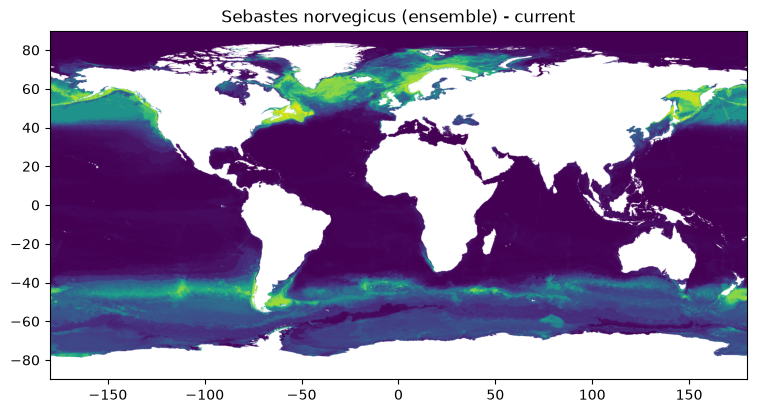

In [7]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

chosen_method = best_method(sp_item["properties"]["methods"])
asset_key = f"method={chosen_method}_scen=current_what=prediction"
pred_href = "/vsicurl/" + s3_to_https(sp_item["assets"][asset_key]["href"])

with rasterio.open(pred_href) as src:
    pred = src.read(1, masked=True)
    transform = src.transform

fig, ax = plt.subplots(figsize=(9, 5))
show(pred, transform=transform, ax=ax, cmap="viridis")
ax.set_title(f"{sp_item['properties']['scientificName']} ({chosen_method}) - current")
plt.show()

Once you have the href for a given asset, you can download it directly (e.g. `requests.get(url).content` written to a file, or in bulk with the AWS CLI / `boto3`, as shown in the [OBIS SDM documentation](https://iobis.github.io/mpaeu_docs/datause.html)) instead of opening it remotely. Using the STAC catalogue this way lets you decide exactly which files to fetch for which species, without having to browse or sync the whole S3 bucket.